# 🧠 10 — Time Series Modeling with LSTM

**Goal**:
In this chapter, we transition from "Tabular Regression" (LightGBM) to **"Sequence Modeling" (LSTM)**.
We aim to capture the **temporal dependencies** (e.g., pollution trends over the last 7 days) to predict the next day's AQI, specifically targeting the "rapid spike" issue.

**Key Concepts**:
1.  **Sliding Window**: Converting time-series data into `(Samples, Time Steps, Features)` format.
2.  **LSTM (Long Short-Term Memory)**: A type of Recurrent Neural Network (RNN) designed to learn long-term dependencies.
3.  **Comparison**: Benchmarking LSTM against our previous LightGBM model.

---

## ⚙️ 01 — Setup & Metadata
Import TensorFlow/Keras and standard data science libraries.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from src.config import PROCESSED_DIR, FIGURE_DIR, MODEL_LSTM_DIR
from src.utils.emoji_log import success, info, task

info(f"Tensorflow Version: {tf.__version__}")
info(f"Num GPUs Available: {len(tf.config.list_physical_devices("GPU"))}")

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

💬 Tensorflow Version: 2.20.0
💬 Num GPUs Available: 0


## 🧱 02 — Data Preparation (Sliding Window)
Unlike LightGBM which takes 2D data `(Rows, Columns)`, LSTM requires 3D data `(Samples, Time Steps, Features)`.
We need to transform our `full_data.parquet` into this sequence format.

---

In [2]:
from src.features.feature_engineering import (
    clip_pollutants,
    handle_outliers_iqr,
    add_rolling_features,
    log_transform_features,
    add_time_features
)

In [3]:
# 1. Load data & filter for one station (optimization for CPU)
df = pd.read_parquet(PROCESSED_DIR / "full_data.parquet")
df["date"] = pd.to_datetime(df["date"])
df

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,winddirec,co_8hr,longitude,latitude,year,month,day,weekday,hour,season
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.9,0.17,35.0,40.2,18.0,...,225.0,0.20,121.038869,24.900097,2024,8,31,5,23,Summer
1,2024-08-31 23:00:00,Zhongming,Taichung_City,50.0,Good,1.6,0.32,27.9,35.1,27.0,...,184.0,0.20,120.641092,24.151958,2024,8,31,5,23,Summer
2,2024-08-31 23:00:00,Zhudong,Hsinchu_County,45.0,Good,0.4,0.17,25.1,40.6,21.0,...,210.0,0.20,121.088955,24.740914,2024,8,31,5,23,Summer
3,2024-08-31 23:00:00,Hsinchu,Hsinchu_City,42.0,Good,0.8,0.20,30.0,35.9,19.0,...,239.0,0.20,120.972368,24.805636,2024,8,31,5,23,Summer
4,2024-08-31 23:00:00,Toufen,Miaoli_County,50.0,Good,1.0,0.16,33.5,35.9,18.0,...,259.0,0.10,120.898693,24.696907,2024,8,31,5,23,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5823857,2016-11-25 13:00:00,Daliao,Kaohsiung_City,77.0,Moderate,8.0,0.54,36.0,12.0,69.0,...,202.0,0.63,120.321268,22.654831,2016,11,25,4,13,Autumn
5823858,2016-11-25 13:00:00,Linyuan,Kaohsiung_City,77.0,Moderate,4.6,0.31,94.0,41.0,30.0,...,224.0,0.46,120.321268,22.654831,2016,11,25,4,13,Autumn
5823859,2016-11-25 13:00:00,Nanzi,Kaohsiung_City,74.0,Moderate,4.2,0.30,90.0,31.0,136.0,...,242.0,0.41,120.321268,22.654831,2016,11,25,4,13,Autumn
5823860,2016-11-25 13:00:00,Zuoying,Kaohsiung_City,99.0,Moderate,6.7,0.62,115.0,40.0,108.0,...,280.0,0.63,120.321268,22.654831,2016,11,25,4,13,Autumn


In [4]:
# 2. Apply Full Feature Engineering Pipeline
task("Applying Feature Engineering...")
df = clip_pollutants(df)
df = handle_outliers_iqr(df)
df = add_rolling_features(df)
df = log_transform_features(df)
df = add_time_features(df)

🚀 Applying Feature Engineering...


✅ The pollutants limit has been set.
✅ IQR has been set.
⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.
✅ Pollutants skewes has been smoothed.
✅ Season encoded successfully.


In [5]:
# 3. Filter for ONE station
target_station = "Taoyuan"
info(f"Filtering data for station: {target_station}")
df_station = df[df["sitename"] == target_station].sort_values("date").copy()

df_station

💬 Filtering data for station: Taoyuan


,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d,season_encoded
5823804,2016-11-25 13:00:00,Taoyuan,Taoyuan_City,26.0,Good,1.163151,0.314811,3.465736,3.465736,2.708050,...,3.396424,3.044523,3.160035,2.606997,2.126100,2.501436,2.684928,1.575536,1.428259,3
5823761,2016-11-25 14:00:00,Taoyuan,Taoyuan_City,26.0,Good,1.163151,0.292670,3.526361,3.465736,3.091043,...,3.377100,3.245193,3.230240,2.280251,1.890039,2.554640,2.694627,1.540445,1.346216,3
5823646,2016-11-25 15:00:00,Taoyuan,Taoyuan_City,26.0,Good,1.335001,0.300105,3.496508,3.465736,3.258096,...,3.342357,3.283414,3.247047,1.897120,1.550597,2.708050,2.736221,1.481605,1.260893,3
5823577,2016-11-25 16:00:00,Taoyuan,Taoyuan_City,26.0,Good,1.504077,0.329304,3.401197,3.465736,3.367296,...,3.316780,3.258096,3.224574,1.609438,1.775858,2.833213,2.745438,1.377926,1.176455,3
5823531,2016-11-25 17:00:00,Taoyuan,Taoyuan_City,26.0,Good,1.504077,0.343590,3.295837,3.465736,3.218876,...,3.316780,3.191847,3.201584,1.466337,2.018227,2.833213,2.726919,1.203973,1.074515,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,2024-08-31 19:00:00,Taoyuan,Taoyuan_City,52.0,Moderate,1.098612,0.357674,4.007333,4.041296,3.433987,...,3.725693,3.455265,3.374169,3.028522,2.995732,2.582739,2.499795,0.725937,0.722706,2
298,2024-08-31 20:00:00,Taoyuan,Taoyuan_City,54.0,Moderate,0.993252,0.350657,3.875359,4.044804,3.465736,...,3.640870,3.444683,3.358638,2.978925,2.957511,2.575154,2.491137,0.757686,0.729961,2
214,2024-08-31 21:00:00,Taoyuan,Taoyuan_City,55.0,Moderate,1.029619,0.336472,3.698830,4.009150,3.465736,...,3.548659,3.320228,3.320228,2.961831,2.961831,2.456736,2.456736,0.709677,0.709677,2
117,2024-08-31 22:00:00,Taoyuan,Taoyuan_City,56.0,Moderate,0.741937,0.307485,3.526361,3.937691,3.401197,...,3.464172,3.238678,3.238678,2.944439,2.944439,2.360854,2.360854,0.717840,0.717840,2


In [6]:
# 4. Select Features
features = [
    "pm2.5",
    "pm10",
    "o3",
    "co",
    "windspeed",
    "pm2.5_rolling_3d",
    "pm2.5_rolling_7d",
    "month",
    "season_encoded",
    "aqi",
]

data = df_station[features].values
data

array([[ 2.79345727,  2.70805025,  3.46573591, ..., 11.        ,
         3.        , 26.        ],
       [ 2.79345727,  3.09104252,  3.52636051, ..., 11.        ,
         3.        , 26.        ],
       [ 2.07944155,  3.25809646,  3.49650764, ..., 11.        ,
         3.        , 26.        ],
       ...,
       [ 2.99573231,  3.46573591,  3.69882989, ...,  8.        ,
         2.        , 55.        ],
       [ 2.99573231,  3.40119743,  3.52636051, ...,  8.        ,
         2.        , 56.        ],
       [ 2.8903718 ,  3.04452252,  3.39785838, ...,  8.        ,
         2.        , 55.        ]], shape=(70929, 10))

In [7]:
# 5. Split Train/Test (Chronological)
train_size = int(len(data) * 0.8)
train_data, test_data = data[:train_size], data[train_size:]

In [8]:
# 6. Scaling
scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [9]:
# 7. Sliding Window
def create_dataset(dataset, look_back=7):
    X, y = [], []
    for i in range(len(dataset) - look_back): # preventing unable to get the last row data
        X.append(dataset[i : i + look_back]) # slicing the data
        y.append(dataset[i + look_back, - 1]) # aqi
    return np.array(X), np.array(y)

LOOK_BACK = 7
X_train, y_train = create_dataset(train_scaled, LOOK_BACK)
X_test,y_test = create_dataset(test_scaled, LOOK_BACK)

info("Data Prepared for LSTM:")
info(f"X_train shape: {X_train.shape}") # Samples, time_step, features_count
info(f"y_train shape: {y_train.shape}")

💬 Data Prepared for LSTM:
💬 X_train shape: (56736, 7, 10)
💬 y_train shape: (56736,)


## 🏗️ 03 — Build LSTM Model
Construct a Sequential model using Keras with LSTM layers and Dropout for regularization.

---

In [10]:
# Get entering shape (Time Steps, Features)
# X_train.shape[1] = 7 (Look back)
# X_train.shape[2] = 10 (Feature count)
input_shape = (X_train.shape[1], X_train.shape[2])

model = Sequential(
    [
        Input(shape=input_shape),
        # First layer LSTM
        # units=50: neuron, adjustable
        # return_sequences=True: Next layer is LSTM as well, so return the sequence
        LSTM(units=50, return_sequences=True),
        Dropout(0.2),  # prevent overfitting (randomly close 20% neuron)
        # Second layer LSTM
        # return_sequences=False: Next layer is Dense, and no need sequence
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        # output layer
        # units=1: only AQI
        Dense(units=1),
    ]
)

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,451 (126.76 KB)

 Trainable params: 32,451 (126.76 KB)

 Non-trainable params: 0 (0.00 B)

## 🚀 04 — Training & Evaluation
Train the model and visualize the Loss Curve to check for overfitting.

---

🚀 Start Training...
Epoch 1/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0025 - val_loss: 7.0407e-04
Epoch 2/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0011 - val_loss: 4.5228e-04
Epoch 3/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 7.0215e-04 - val_loss: 3.6217e-04
Epoch 4/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5.4418e-04 - val_loss: 2.9955e-04
Epoch 5/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 4.7350e-04 - val_loss: 3.8328e-04
Epoch 6/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 4.5835e-04 - val_loss: 2.2273e-04
Epoch 7/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 4.3730e-04 - val_loss: 2.2530e-04
Epoch 8/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 4.1043e-04 - val_loss: 2.2242e-04
Epoch 9/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 3.9644e-04 - val_loss: 2.1222e-04
Epoch 10/20
1419/1419 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 3.9597e-04 - val_loss: 2.0401e-04
Epoch 11/20

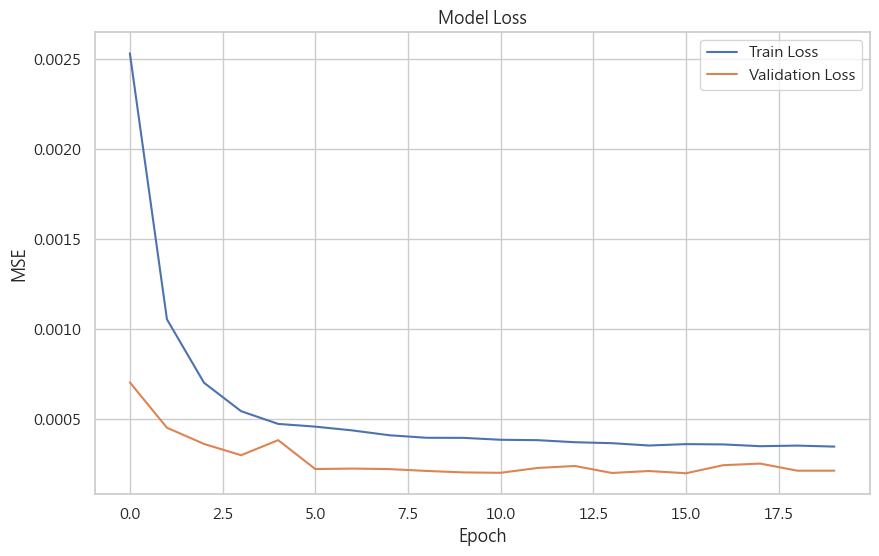

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_path = MODEL_LSTM_DIR / "latest.keras"
# Setting Callbacks
callbacks = [
    # If validation loss doesn't improve for 5 epochs, stop training
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    # Save the best model
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_loss', save_best_only=True)
]

print("🚀 Start Training...")
history = model.fit(
    X_train, y_train,
    epochs=20,           # do 20 epochs most
    batch_size=32,       # read 32 rows at a time
    validation_split=0.2, # split 20% from validation to be the test
    callbacks=callbacks,
    verbose=1
)

# Drawing loss curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 📉 05 — Prediction & Comparison
Visualize the predictions against actual values, specifically focusing on peak pollution events.

---

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [13]:
# 1. Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

1773/1773 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [14]:
# 2. Inverse Transform (Return the actual AQI)
def invert_transform_aqi(pred_array, scaler):
    # Create an array with the same width as features and fill it with 0
    dummy = np.zeros((len(pred_array), 10)) # (row_count, column_count)
    # Fill the predictions to the last column (AQI)
    dummy[:, -1] = pred_array[:, 0]
    # Inverse transform
    inversed = scaler.inverse_transform(dummy)
    # Get the last column
    return inversed[:, -1]
y_train_inv = invert_transform_aqi(y_train.reshape(-1, 1), scaler)
y_test_inv = invert_transform_aqi(y_test.reshape(-1, 1), scaler)
train_predict_inv = invert_transform_aqi(train_predict, scaler)
test_predict_inv = invert_transform_aqi(test_predict, scaler)


In [15]:
# 3. Calculate Scores
rmse = math.sqrt(mean_squared_error(y_test_inv, test_predict_inv))
mae = mean_absolute_error(y_test_inv, test_predict_inv)
info(f"Test RMSE: {rmse:.2f}")
info(f"Test MAE: {mae:.2f}")

💬 Test RMSE: 2.89
💬 Test MAE: 1.77


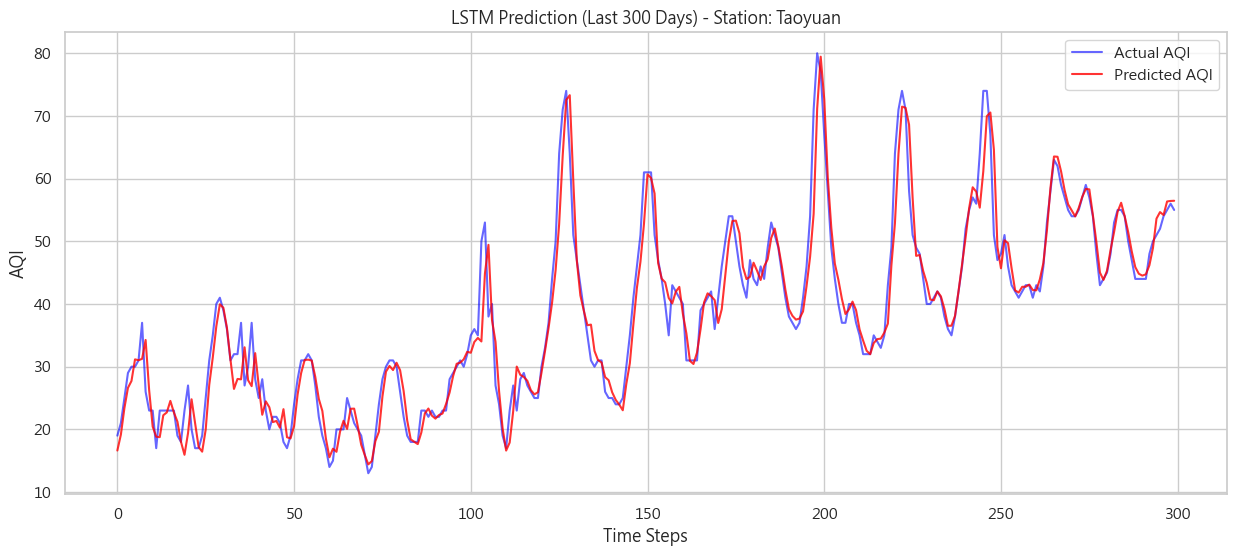

In [16]:
# 4. Plotting
plt.figure(figsize=(15, 6))

subset_n = 300
plt.plot(y_test_inv[-subset_n:], label="Actual AQI", color="blue", alpha=0.6)
plt.plot(test_predict_inv[-subset_n:], label="Predicted AQI", color="red", alpha=0.8)

plt.title(f'LSTM Prediction (Last {subset_n} Days) - Station: {target_station}')
plt.xlabel('Time Steps')
plt.ylabel('AQI')
plt.legend()
plt.show()